### Importing Libraries

In [259]:
import pandas as pd
import numpy as np
import re 
import datetime

# Exploratory Data Analysis & Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection & Preprocessing 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Class imbalance 
#from imbalanced-learn.over_sampling import SMOTE


# Model 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
#import lightgbm as lgb

# Model Evaluation 
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve)

# Explainability
#import SHAP

print("Import successful")

Import successful


### Loading the data

In [210]:
df_transaction = pd.read_csv(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\FinLora_Customer_Transaction_Dataset.csv")

# Make a copy for reference to original data
df_transaction_copy = df_transaction.copy() 

### Data Dictionary — FinLora Transaction Dataset

| # | Column | Description |
|---|--------|--------------|
| 0 | `transaction_id` | Unique identifier for each transaction. |
| 1 | `customer_id` | Unique identifier for the customer who initiated the transaction. |
| 2 | `timestamp` | Date and time the transaction occurred (UTC). |
| 3 | `home_country` | Customer's registered home/residence country. |
| 4 | `source_currency` | Currency the transaction was sent in. |
| 5 | `dest_currency` | Currency the transaction was received in. |
| 6 | `channel` | Payment channel used to initiate the transaction (e.g., ATM, web, mobile). |
| 7 | `amount_src` | Transaction amount in the source currency. |
| 8 | `amount_usd` | Source transaction amount converted to USD, for standardised comparison across currencies. |
| 9 | `fee` | Fee charged on the transaction. |
| 10 | `exchange_rate_src_to_dest` | Exchange rate applied between source and destination currency at time of transaction. |
| 11 | `device_id` | Identifier for the device used to initiate the transaction. |
| 12 | `new_device` | Whether the transaction was initiated from a device not previously associated with the customer (True/False). |
| 13 | `ip_address` | IP address the transaction originated from. |
| 14 | `ip_country` | Country inferred from the transaction's IP address. |
| 15 | `location_mismatch` | Whether the customer's declared/home location differs from the IP-inferred location (True/False) — a common fraud signal. |
| 16 | `ip_risk_score` | Risk score associated with the originating IP address (e.g., linked to VPNs, proxies, known bad actors). |
| 17 | `kyc_tier` | Customer's Know Your Customer verification level/tier (Enhanced, Low, Standard). |
| 18 | `account_age_days` | Number of days since the customer's account was created. |
| 19 | `device_trust_score` | Trust/reputation score associated with the device used to initiate transaction. |
| 20 | `chargeback_history_count` | Number of prior chargebacks associated with the customer — historical fraud/dispute signal. |
| 21 | `risk_score_internal` | FinLora's existing internal risk score (likely output of the current rule-based system) for the transaction. |
| 22 | `txn_velocity_1h` | Number of transactions made by the customer in the past 1 hour. |
| 23 | `txn_velocity_24h` | Number of transactions made by the customer in the past 24 hours. |
| 24 | `corridor_risk` | Risk score associated with the specific source-to-destination country/currency "corridor" (some corridors are higher-risk for fraud/money laundering). |
| 25 | `is_fraud` | **Target variable.** Indicates whether the transaction was confirmed fraudulent (1) or legitimate (0). |

### Initial Data Quality Checks 

In [211]:
# Checking the first 5 transactions in the data
df_transaction.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [212]:
# Checking for number of records and features in the given data 
print(f"The data has {df_transaction.shape[0]} financial transactions records and {df_transaction.shape[1]} features ")

The data has 11400 financial transactions records and 26 features 


In [213]:
# Checking for duplicate transaction_id
print(f"There are {df_transaction.duplicated(subset='transaction_id').sum()} duplicate records in the data")

# print(f"There are {df_transaction.duplicated().sum()} duplicate transaction_ids in the data")

There are 200 duplicate records in the data


In [214]:
# Check for data types and missing values 
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [215]:
# Checking for null values in features 

df_transaction.isnull().sum()
#(df_transaction.isnull().mean()*100).round(2)

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

The missing values across the dataset are minimal and not a cause for concern — generally under 3% per column. These will be addressed in the data cleaning steps that follow.

In [216]:
# Converting timestamp to datetime data type 
df_transaction["timestamp"] = pd.to_datetime(df_transaction["timestamp"], errors="coerce")

# Converting amount_src to numeric data 
df_transaction["amount_src"] = pd.to_numeric(df_transaction["amount_src"], errors= "coerce")

In [217]:
# Sanity check - Object data types check 
object_cols = df_transaction.select_dtypes(include='object').columns

for col in object_cols:
    unique_types = df_transaction[col].apply(lambda x: type(x).__name__).value_counts()
    print(f"Column: {col}")
    print(unique_types)
    print("-" * 40)

Column: transaction_id
transaction_id
str    11400
Name: count, dtype: int64
----------------------------------------
Column: customer_id
customer_id
str    11400
Name: count, dtype: int64
----------------------------------------
Column: home_country
home_country
str    11400
Name: count, dtype: int64
----------------------------------------
Column: source_currency
source_currency
str    11400
Name: count, dtype: int64
----------------------------------------
Column: dest_currency
dest_currency
str    11400
Name: count, dtype: int64
----------------------------------------
Column: channel
channel
str    11400
Name: count, dtype: int64
----------------------------------------
Column: device_id
device_id
str    11400
Name: count, dtype: int64
----------------------------------------
Column: ip_address
ip_address
str      11095
float      305
Name: count, dtype: int64
----------------------------------------
Column: ip_country
ip_country
str      11099
float      301
Name: count, dtype: i

In [218]:
# Sanity check 
df_transaction.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

The `timestamp` and `amount_src` columns were converted to datetime and numeric (float) data types respectively. Using `errors='coerce'` allows the conversion to proceed without breaking, by converting any unparseable or invalid values to nulls rather than raising an error. As a result, the number of missing values specifically for timestamp increased from 29 to 61, as confirmed in the sanity checks above.

#### Handling data inconsistencies in categorical columns 

In [219]:
# Checking for unique values in categorical values

cat_cols = ["home_country", "source_currency", "dest_currency", "channel", "ip_country", "kyc_tier"]

for col in cat_cols:
    print(f"\n{col}")
    print(df_transaction[col].unique())
    print("-" * 40)


home_country
['US' 'CA' 'UK' ' UK  ' ' US  ' 'unknown' ' CA  ']
----------------------------------------

source_currency
['USD' 'CAD' 'GBP']
----------------------------------------

dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']
----------------------------------------

channel
['ATM' 'web' 'mobile' 'WEB' ' web  ' 'MOBILE' 'mobille' 'unknown'
 ' mobile  ' 'weeb' 'ATm' ' ATM  ']
----------------------------------------

ip_country
['US' 'CA' nan 'UK' ' US  ' 'NAN' 'unknown' ' CA  ' ' UK  ' ' nan  ']
----------------------------------------

kyc_tier
['standard' 'enhanced' 'low' ' standard  ' nan 'standrd' ' enhanced  '
 'STANDARD' 'NAN' 'unknown' 'enhancd' ' low  ' 'ENHANCED' 'LOW' ' nan  ']
----------------------------------------


In [220]:
# Standardising categorical text columns 
# Step 1 - Removing whitespaces

for cols in cat_cols:
    df_transaction[cols] = (df_transaction[cols].str.strip().str.replace(r'\s+', ' ', regex=True))

In [221]:
# Changingig specific columns to lowercase 

cat_cols_lower = ["channel", "kyc_tier"]

for cols in cat_cols_lower:
    df_transaction[cols] = (df_transaction[cols].str.lower())

In [222]:
# Step 2 - Correcting spellings

cat_cols_dict = {"mobille": "mobile", "weeb": "web", "standrd": "standard", "enhancd": "enhanced"}

for col in cat_cols_lower:
    df_transaction[col] = df_transaction[col].replace(cat_cols_dict)

In [223]:
# Step 3 - Replacing placeholder values with numpy null

place_holder_misisng = ["unknown", "nan", "NAN"]

for cols in cat_cols:
    df_transaction[cols] = df_transaction[cols].replace(place_holder_misisng,np.nan)

In [224]:
# Sanity check
for col in cat_cols:
    print(f"\n{col}")
    print(df_transaction[col].unique())
    print("-" * 40)


home_country
['US' 'CA' 'UK' nan]
----------------------------------------

source_currency
['USD' 'CAD' 'GBP']
----------------------------------------

dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']
----------------------------------------

channel
['atm' 'web' 'mobile' nan]
----------------------------------------

ip_country
['US' 'CA' nan 'UK']
----------------------------------------

kyc_tier
['standard' 'enhanced' 'low' nan]
----------------------------------------


In [225]:
# Sanity check 
df_transaction.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                  32
source_currency                0
dest_currency                  0
channel                       37
amount_src                     4
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   337
location_mismatch              0
ip_risk_score                  0
kyc_tier                     335
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

A review of the unique values across categorical columns revealed several inconsistencies, including inconsistent spelling (e.g., `mobille` instead of `mobile`), inconsistent casing, and leading/trailing whitespace. These were standardised by converting text to lowercase, stripping whitespace, and correcting known misspellings.

In addition, some columns contained placeholder values such as `"unknown"`, `"nan"`, and `"NAN"`, which were not recognised by pandas as missing data. These placeholders were replaced with proper null values (`NaN`), which caused a subsequent increase in the missing value counts for the affected columns, as they now accurately reflect the true extent of missing data rather than being masked by placeholder text.

### Data Quality Check - Numeric Features 

In [226]:
# Numeric Feature Summary — Central Tendencies & Negative Value Check

df_transaction.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_src,11396.0,436.103368,1370.609043,-9997.160,90.6575,158.925000,294.640000,11942.890000
amount_usd,11095.0,452.022083,1403.973062,7.230,92.4650,163.480000,302.190000,12498.570000
fee,11105.0,100.309441,958.128504,-1.000,2.3800,3.500000,5.550000,9999.990000
exchange_rate_src_to_dest,11400.0,167.540397,382.023827,0.592,1.0000,7.142857,73.529412,1388.888889
ip_risk_score,11400.0,0.396726,0.270507,0.004,0.2090,0.325000,0.487000,1.200000
account_age_days,11400.0,393.793158,342.348393,1.000,147.0000,298.000000,661.000000,1095.000000
device_trust_score,11105.0,0.653681,0.273012,-0.100,0.5150,0.658000,0.894000,0.999000
chargeback_history_count,11400.0,0.048509,0.256194,0.000,0.0000,0.000000,0.000000,2.000000
risk_score_internal,11400.0,0.267134,0.142983,0.000,0.1690,0.223000,0.391000,0.900000
txn_velocity_1h,11400.0,0.458333,1.524494,-1.000,0.0000,0.000000,0.000000,8.000000




A transposed `describe()` output was used to review all numeric columns at a glance. Several columns show **negative minimum values that are not logically valid**, flagging them for correction in the next data quality step:

- `amount_src`, `fee` — transaction amounts and fees should never be negative.
- `device_trust_score` — expected to fall within 0–1; a small negative minimum (-0.1) suggests a data artifact.
- `txn_velocity_1h` — a transaction count cannot logically be negative.

Columns such as `ip_risk_score`, `chargeback_history_count`, `risk_score_internal`, `txn_velocity_24h`, and `corridor_risk` show valid, non-negative ranges consistent with expectations.

The target variable, `is_fraud`, shows a mean of **~8.9%**, suggesting a class imbalance as expected in the project.

These findings will guide the outlier and invalid-value correction step that follows.

In [228]:
# How many negative values are in the affected features?

negative_cols = ["amount_src", "fee", "device_trust_score", "txn_velocity_1h"]

negative_counts = (df_transaction[negative_cols] < 0).sum()

negative_pct = (df_transaction[negative_cols] < 0).mean() * 100
negative_pct.round(2)

pd.DataFrame({
    "negative_count": negative_counts,
    "negative_pct": negative_pct.round(2)
})

,negative_count,negative_pct
amount_src,103,0.90
fee,101,0.89
device_trust_score,204,1.79
txn_velocity_1h,204,1.79


In [230]:
# Drop all records with negative numeric values

# Build a mask: True for any row where ANY of these columns is negative
negative_mask = (df_transaction[negative_cols] < 0).any(axis=1)

print(f"Rows to be dropped: {negative_mask.sum()}")

df_transaction = df_transaction[~negative_mask]

Rows to be dropped: 204


All rows containing negative values in numeric features that logically cannot be negative — such as transaction amounts, fees, and trust scores — were dropped to maintain data quality.

In [233]:
# Sanity check - Cleaned measures of central tendency for the data
df_transaction.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_src,11196.0,444.923434,1377.465217,7.230,92.115,160.540000,297.357500,11942.890000
amount_usd,10901.0,452.290216,1402.198599,7.230,92.470,163.480000,302.480000,12497.900000
fee,10901.0,7.709235,20.757587,0.500,2.400,3.500000,5.490000,179.740000
exchange_rate_src_to_dest,11196.0,168.172179,382.780084,0.592,1.000,7.142857,73.529412,1388.888889
ip_risk_score,11196.0,0.382090,0.250070,0.004,0.207,0.320000,0.474000,1.000000
account_age_days,11196.0,393.529207,342.149646,1.000,147.000,298.000000,661.000000,1095.000000
device_trust_score,10901.0,0.667785,0.255148,0.005,0.522,0.702000,0.894000,0.999000
chargeback_history_count,11196.0,0.049303,0.258277,0.000,0.000,0.000000,0.000000,2.000000
risk_score_internal,11196.0,0.267430,0.143505,0.000,0.169,0.223000,0.391000,0.900000
txn_velocity_1h,11196.0,0.484905,1.525442,0.000,0.000,0.000000,0.000000,8.000000


### Data Quality Check - Timestamp

In [262]:
# Checking for futuristic timestamp 

# Check the date range of your data first, for context
print(f"Earliest timestamp: {df_transaction['timestamp'].min()}")
print(f"Latest timestamp: {df_transaction['timestamp'].max()}")

future_timestamps = df_transaction[df_transaction["timestamp"] > pd.Timestamp.now(tz="UTC")]
print(f"Number of futuristic timestamps: {future_timestamps.shape[0]}")

Earliest timestamp: 2022-10-03 18:40:59.468549+00:00
Latest timestamp: 2025-12-16 00:13:41.468549+00:00
Number of futuristic timestamps: 0


### Handling Duplicate Transaction IDs

In [234]:
# Checking to see if duplicate transaction IDs are exact across all features

duplicate_transactions = df_transaction[df_transaction.duplicated(subset='transaction_id', keep=False)]
inconsistent = duplicate_transactions.groupby('transaction_id').nunique()
inconsistent[(inconsistent > 1).any(axis=1)]

,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,


In [235]:
# Dropping duplicate transaction IDs

df_transaction = df_transaction.drop_duplicates(subset="transaction_id", keep="first")

In [236]:
# Sanity check 

print(f"There are {df_transaction.duplicated().sum()} duplicates in the data")
print(f"There are now {df_transaction.shape[0]} records in the data")

There are 0 duplicates in the data
There are now 11000 records in the data


An earlier check identified 200 duplicate `transaction_id` values in the dataset. Before removing them, it was important to confirm whether these duplicates represented the same transaction recorded twice, or conflicting records mistakenly sharing the same ID.

A comparison across all other columns for each duplicated `transaction_id` showed no inconsistencies — every duplicate pair matched exactly across all features. This confirmed that the duplicates were genuine repeat entries of the same transaction, rather than data errors requiring further investigation.

With this confirmed, the extra copies were removed, retaining only the first occurrence of each transaction. This ensured that each transaction is represented once in the dataset, preserving data integrity for the analysis and modelling phases ahead.

### Investigating the Nature of Missing Values

In [237]:
# Missingness Analysis - Understanding if the missing features are significantly related to fradulent transactions

missing_cols = ['timestamp', 'home_country', 'channel', 'amount_src', 'amount_usd',
                'fee', 'ip_address', 'ip_country', 'kyc_tier', 'device_trust_score']

missing_by_fraud = df_transaction.groupby('is_fraud')[missing_cols].apply(lambda x: x.isnull().mean() * 100).T
missing_by_fraud.columns = ['Missing % (Legit)', 'Missing % (Fraud)']
missing_by_fraud.round(2)

,Missing % (Legit),Missing % (Fraud)
timestamp,0.58,0.20
home_country,0.31,0.10
channel,0.36,0.10
amount_src,0.00,0.00
amount_usd,2.83,0.71
fee,2.83,0.71
ip_address,2.83,0.71
ip_country,3.14,0.71
kyc_tier,3.11,0.81
device_trust_score,2.83,0.71


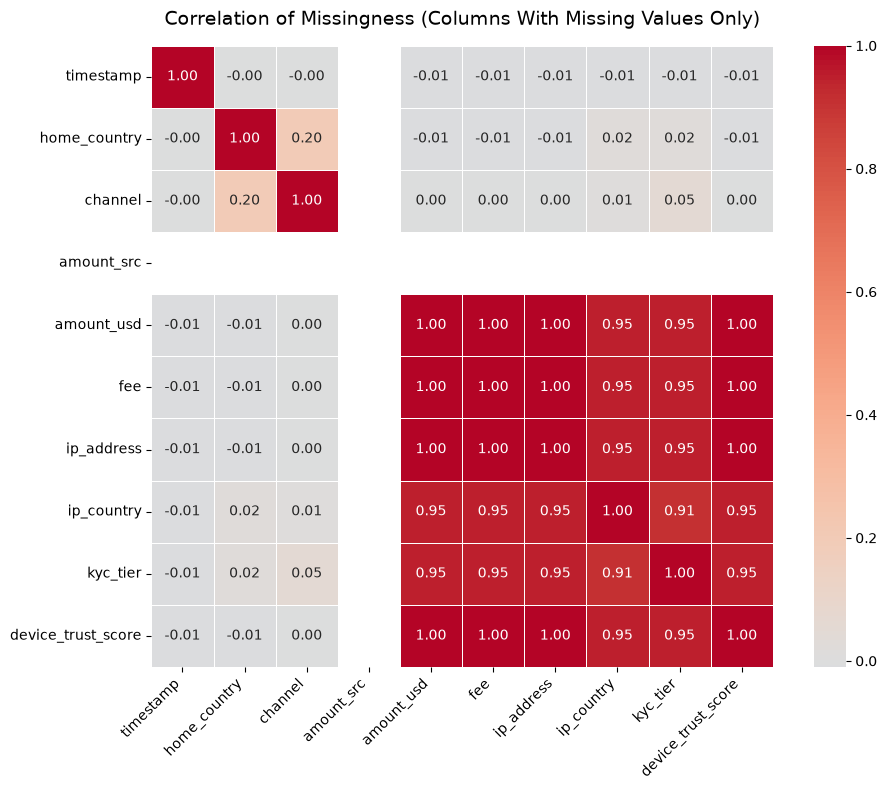

In [238]:
# Checking for correlation of "is missing" across columns (1 = always missing together, 0 = unrelated)

missing_corr = df_transaction[missing_cols].isnull().corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation of Missingness (Columns With Missing Values Only)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Beyond simply quantifying missing values, it was important to understand *why* they were missing — specifically, whether the missingness was random or systematically linked to fraudulent transactions or any other feature in the dataset. This distinction matters because non-random missingness can itself carry predictive signal, and handling it carelessly (e.g., blindly imputing or dropping rows) risks erasing that signal.

**Correlation of Missingness**

A correlation matrix was built on the "is-missing" indicator (`True`/`False`) for each column with missing values, to check whether columns tend to go missing together. The resulting heatmap revealed a clear pattern: `amount_usd`, `fee`, `ip_address`, `ip_country`, `kyc_tier`, and `device_trust_score` are strongly correlated with one another in their missingness, with correlation values ranging from approximately 0.92 to 1.00. This indicates that when one of these six fields is missing on a given transaction, the others are very likely missing as well — the gaps do not occur independently, but as a shared block.

In contrast, `timestamp` and `amount_src` showed near-zero correlation with this block and with each other, confirming their missingness is unrelated and can be treated independently.

In [239]:
# Does this missingness relate to any other feature? 
# Channel

overlap_cols = ['amount_usd', 'fee', 'ip_address', 'ip_country', 'kyc_tier', 'device_trust_score']

df_transaction.groupby('channel')[overlap_cols].apply(lambda x: x.isnull().mean() * 100).round(1)

,amount_usd,fee,ip_address,ip_country,kyc_tier,device_trust_score
channel,,,,,,
atm,2.7,2.7,2.7,2.9,3.0,2.7
mobile,2.9,2.9,2.9,3.2,3.2,2.9
web,2.1,2.1,2.1,2.4,2.2,2.1


In [240]:
# Home_country

df_transaction.groupby('home_country')[overlap_cols].apply(lambda x: x.isnull().mean() * 100).round(1)

,amount_usd,fee,ip_address,ip_country,kyc_tier,device_trust_score
home_country,,,,,,
CA,1.8,1.8,1.8,2.0,1.8,1.8
UK,3.2,3.2,3.2,3.4,3.5,3.2
US,2.6,2.6,2.6,2.9,2.9,2.6


In [241]:
# Checking other possible feature

other_cols_to_check = ['source_currency', 'dest_currency', 'new_device', 'location_mismatch']

for col in other_cols_to_check:
    print(f"\n=== Missingness by {col} ===")
    print(df_transaction.groupby(col)[overlap_cols].apply(lambda x: x.isnull().mean() * 100).round(1))


=== Missingness by source_currency ===
                 amount_usd  fee  ...  kyc_tier  device_trust_score
source_currency                   ...                              
CAD                     1.8  1.8  ...       1.8                 1.8
GBP                     3.2  3.2  ...       3.5                 3.2
USD                     2.6  2.6  ...       2.9                 2.6

[3 rows x 6 columns]

=== Missingness by dest_currency ===
               amount_usd  fee  ...  kyc_tier  device_trust_score
dest_currency                   ...                              
CAD                   2.6  2.6  ...       2.8                 2.6
CNY                   2.2  2.2  ...       2.3                 2.2
EUR                   3.3  3.3  ...       3.7                 3.3
GBP                   3.0  3.0  ...       3.2                 3.0
INR                   2.6  2.6  ...       3.0                 2.6
MXN                   3.0  3.0  ...       3.1                 3.0
NGN                   2.9  2.9  

#### Searching for a Root Cause

Given that these six columns move together, the next step was to determine whether this pattern could be explained by any other feature in the dataset — that is, whether missingness was concentrated within a specific category (Missing At Random, conditional on an observed feature) rather than occurring at random overall.

The missingness rate for this block of six columns was compared across every relevant categorical feature available: `channel`, `home_country`, `source_currency`, `dest_currency`, and `new_device`. In each case, the missingness rate remained fairly consistent across all categories (typically ranging narrowly between 1.8% and 3.5%), with no category showing a disproportionately higher or lower rate. No feature in the dataset could account for why these six columns are missing together.

**Conclusion**

Since these six columns are missing together but this pattern could not be traced to any other feature or to fraud outcomes, the missingness cannot be classified as fully random or explained by a known cause — it is most likely driven by a shared upstream process (e.g., a single enrichment step that succeeds or fails as a unit).

As no explanatory driver was found, standard imputation will be used accordingly

### Handling Missing Records

Missing values were addressed individually for each affected column, guided by the earlier finding that six columns (`amount_usd`, `fee`, `ip_address`, `ip_country`, `kyc_tier`, `device_trust_score`) were missing together as a correlated block with no identifiable root cause, alongside three independent columns (`timestamp`, `home_country`, `channel`, `amount_src`) with unrelated, low-volume gaps. Rather than applying a single blanket method, each column was treated based on its relationship to other features in the data.

#### Categorical Variables

- **`home_country`** — A check confirmed a 100% match rate between `source_currency` and `home_country`, meaning currency reliably predicts a customer's registered country in this dataset. Missing values were filled using a currency-to-country mapping.
- **`ip_country`** — Handled the same way as `home_country`, using the currency-to-country mapping, since the relationship held consistently.
- **`channel`** — No related column could reliably predict `channel`. With only 37 missing values, it was imputed using the mode (most frequent channel).
- **`kyc_tier`** — Missingness in this column could not be traced to any other feature. Given that KYC tier reflects a customer's verification status — a sensitive attribute directly tied to compliance and risk — imputing a specific tier risked misrepresenting an unverified or unknown customer as verified. Missing values were instead filled with a placeholder category, `"not_captured"`, preserving the fact that verification status was genuinely unknown rather than making an assumption that could understate risk.

#### Numeric Variables

- **`amount_src`** — Only 4 rows were affected. Given the negligible volume and the risk of fabricating a transaction amount, these rows were dropped.
- **`amount_usd`** — Rather than a simple median, `amount_usd` was reconstructed using the implied exchange rate (`amount_usd / amount_src`) for each `source_currency`. The median implied rate per currency was used to convert `amount_src` into a filled `amount_usd` value, preserving the true currency-conversion relationship between the two columns.
- **`fee`** — `fee` was found to be a consistent ~2% of `amount_src`, regardless of currency or channel. Missing values were filled by applying this ratio to `amount_src`, and a standardised `fee_usd` column was added for cross-currency comparison.
- **`device_trust_score`** — Trust scores varied meaningfully by both `new_device` and `kyc_tier`, with the two factors compounding (e.g., a new device from a low-KYC customer scored far lower than a new device from an enhanced-KYC customer). Missing values were therefore filled using the median `device_trust_score`, grouped by both `new_device` and `kyc_tier` together, rather than a single overall median.

#### `timestamp`

With only 61 missing values and `timestamp` being central to time-based features (e.g., transaction velocity), rows with missing timestamps were dropped rather than imputed, given the negligible impact on overall dataset size.

#### Summary

Across both categorical and numeric variables, imputation was guided by evidence rather than convenience — relationships between columns (currency, device history, verification tier) were tested and used wherever they held, and simpler fallback methods (mode, placeholder categories, or dropping) were reserved for columns with no reliable predictive relationship or negligible missing volume.

In [242]:
# Timestamp - Drop all 61 rows will empty timestamp
df_transaction = df_transaction.dropna(subset=["timestamp"])

In [243]:
# amount_src - Dropp all 4 missing transaction amount
df_transaction = df_transaction.dropna(subset=["amount_src"])

In [244]:
# IP Country - Fill 337 missing ip_country with corresponding source country currency country 

# Create a dictionary of currency - country 
currency_country_map = {"CAD": "CA", "GBP": "UK", "USD": "US"}

# Fill im missing IP country with currency_country_map
mapped_country = df_transaction["source_currency"].map(currency_country_map)
df_transaction["ip_country"] = df_transaction["ip_country"].fillna(mapped_country)

In [245]:
# Home Country - Fill in 32 missing home countries

# Step 1 - Check if home_country is always were customer transactions are made from

# Build a home_country_currency map
home_currency_map = currency_country_map

# Only check rows where home_country is known (not missing)
df_check = df_transaction.dropna(subset=['home_country']).copy()

# Apply the mapping to get the "expected" country based on source_currency
df_check['expected_home_country'] = df_check['source_currency'].map(home_currency_map)

# Compare expected vs actual
match_rate = (df_check['home_country'] == df_check['expected_home_country']).mean() * 100

print(f"Match rate: {match_rate:.2f}%")

Match rate: 100.00%


In [246]:
# Step 2 - Fill im missing Home country with home_currency_country_map
mapped_home_country = df_transaction["source_currency"].map(home_currency_map)
df_transaction["home_country"] = df_transaction["home_country"].fillna(mapped_home_country)

In [247]:
# Channel - Fill the 37 missing channels

df_transaction["channel"] = df_transaction["channel"].fillna(df_transaction["channel"].mode()[0])

In [248]:
# KYC Tier - Fill the 335 missing Know Your Customer Tier 

df_transaction["kyc_tier"] = df_transaction["kyc_tier"].fillna("not_captured")

In [249]:
# Amount Source - 

# Calculating the median exchange rate 

median_rate_by_currency = (df_transaction.dropna(subset=["amount_usd"])
    .assign(rate=lambda x: x["amount_usd"] / x["amount_src"])
    .groupby("source_currency")["rate"]
    .median()
)

print(median_rate_by_currency)

source_currency
CAD    0.74
GBP    1.25
USD    1.00
Name: rate, dtype: float64


In [250]:
# Filling the amount_usd missing values 
mapped_rate = df_transaction["source_currency"].map(median_rate_by_currency)

df_transaction["amount_usd"] = df_transaction["amount_usd"].fillna(df_transaction["amount_src"] * mapped_rate)

In [251]:
# Fees

# Step 1 - Checking if the fees column is standardised to USD 
df_check1 = df_transaction.dropna(subset=["fee", "amount_usd", "amount_src"])

df_check1.assign(
    fee_to_usd_ratio=lambda x: x["fee"] / x["amount_usd"],
    fee_to_src_ratio=lambda x: x["fee"] / x["amount_src"]
).groupby("source_currency")[["fee_to_usd_ratio", "fee_to_src_ratio"]].describe()

fee_to_usd_ratio            ... fee_to_src_ratio          
                           count      mean  ...              75%       max
source_currency                             ...                           
CAD                       1165.0  0.031062  ...         0.024720  0.080966
GBP                       1988.0  0.018675  ...         0.025703  0.145022
USD                       7497.0  0.023748  ...         0.026223  0.173913

[3 rows x 16 columns]

In [252]:
# Step 2 - Checking to see if fees depend on channel of transaction in relation to amount src

df_transaction.dropna(subset=["fee", "amount_src"]).assign(
    fee_ratio=lambda x: x["fee"] / x["amount_src"]
).groupby("channel")["fee_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
atm,951.0,0.023438,0.010357,0.010966,0.017420,0.020285,0.025565,0.148515
mobile,6091.0,0.023873,0.010332,0.006093,0.017715,0.020823,0.026284,0.173913
web,3608.0,0.023151,0.009972,0.009168,0.017083,0.020151,0.025484,0.145022


In [253]:
df_transaction.dropna(subset=["fee", "amount_src"]).assign(
    fee_ratio=lambda x: x["fee"] / x["amount_src"]
).groupby(["source_currency", "channel"])["fee_ratio"].median().unstack()

channel,atm,mobile,web
source_currency,,,
CAD,0.021038,0.021071,0.018675
GBP,0.020262,0.020516,0.019906
USD,0.020258,0.020858,0.020557


In [254]:
# Step 3 - Fill 295 missing fees

median_fee_ratio = (df_transaction.dropna(subset=["fee", "amount_src"])
    .assign(fee_ratio=lambda x: x["fee"] / x["amount_src"])
    .groupby("source_currency")["fee_ratio"]
    .median()
)

mapped_fee_ratio = df_transaction["source_currency"].map(median_fee_ratio)

df_transaction["fee"] = df_transaction["fee"].fillna(df_transaction["amount_src"] * mapped_fee_ratio)

In [255]:
# Step 4 - Create a standardised column for fees in USD

mapped_rate = df_transaction["source_currency"].map(median_rate_by_currency)
df_transaction["fee_usd"] = df_transaction["fee"] * mapped_rate

In [256]:
# Device trust score missing value inputation 

# Step 1 - Check if device trust score is affected by the use of a new device and customer tier 

# Trust score by new device and kyc tier 
df_transaction.dropna(subset=["device_trust_score"]).groupby(["new_device", "kyc_tier"])["device_trust_score"].median().unstack()

kyc_tier,enhanced,low,not_captured,standard
new_device,,,,
False,0.939,0.5150,0.892,0.625
True,0.744,0.1835,0.401,0.372


In [257]:
# Step 2 - Fill 295 missing devcie trust scores with median trust score of new_device/kyc_tier score

df_transaction["device_trust_score"] = df_transaction["device_trust_score"].fillna(
df_transaction.groupby(["new_device", "kyc_tier"])["device_trust_score"].transform("median"))

In [258]:
# Sanity Check for missing values imputation 
df_transaction.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                      0
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   290
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
fee_usd                        0
dtype: int64